# tSNE to classify glitches in O3a observation run from Virgo interferometer

This code will use data from O3b observation run from LIGO interferometer to generate glitchgrams. From these, we will construct SNR matrices that will be vectorized. We will apply these vectors to tSNE and plot the scatterplot to see the class separations. **It is worth noting that the color visualization will be possible because the classification (glitch labels) has already been done by Gravity Spy. Thus, we only want to confirm if our classification is correct.**

In [2]:
import os
import uproot
# import fsspec

import pandas as pd
# import csv
import glob

import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Find the data

Let's start by examining the files in the current path and reading the triggers for the LIGO O3b run.

In [5]:
os.getcwd()

'/home/esanches/Projetos/tSNE/Virgo'

In [6]:
os.listdir('/home/esanches/Projetos/tSNE/Virgo/zomicron')

['V1-Hrec_hoft_16384Hz_OMICRON-1260018420-981586.root',
 '.ipynb_checkpoints',
 'V1-Hrec_hoft_16384Hz_OMICRON-1256655397-344607.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1250940724-3036664.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1246809087-1690919.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1248500006-2422529.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1241261064-2538939.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1258300000-1697031.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1257900005-399995.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1257000004-400003.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1245600007-1087596.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1261000006-1999999.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1263000005-3221672.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1266669388-830612.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1243800003-1800004.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1267500000-2172312.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1238165004-3080979.root',
 'V1-Hrec_hoft_16384Hz_OMICRON-1257400007-499998.root']

In [7]:
path = '/home/esanches/Projetos/tSNE/Virgo/zomicron/V1-Hrec_hoft_16384Hz_OMICRON-1260018420-981586.root'
os.path.exists(path)

True

The **.root** files contain trees that can be accessed. The **keys()** show us the branches of that tree.

In [8]:
file = uproot.open(path)
file.keys()

['triggers;1', 'metadata;1', 'segments;1']

Let's follow the first one ramification:

In [9]:
tree = file['triggers;1']
tree.keys()

['time',
 'frequency',
 'q',
 'snr',
 'tstart',
 'tend',
 'fstart',
 'fend',
 'amplitude',
 'phase',
 'tstart_ms']

these are the columns that we can access

## Process the triggers and glitches and save them as a .csv.

You need to run these only once. If you already created the triggers and glitches in **.csv** files, go to the **Create the glitchgrams** section.

### Triggers (.root) ~ we will use "uproot" to read the files

In [71]:
folder = "/home/esanches/Projetos/VIRGO_tsne/VIRGO/zomicron"
files = [f for f in os.listdir(folder) if f.endswith(".root")]

saida_csv = "/home/esanches/Projetos/VIRGO_tsne/VIRGO/triggers_total.csv"
first = True   # write the header only one time

for arq in files:
    print(f"Reading: {arq}")
    
    caminho = os.path.join(folder, arq)
    
    with uproot.open(caminho) as f:
        tree = f["triggers;1"]
        df = tree.arrays(["time", "frequency", "snr"], library="pd")

    df.to_csv(saida_csv, mode="w" if first else "a", header=first, index=False)

    first = False
    del df

Reading: V1-Hrec_hoft_16384Hz_OMICRON-1260018420-981586.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1256655397-344607.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1250940724-3036664.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1246809087-1690919.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1248500006-2422529.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1241261064-2538939.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1258300000-1697031.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1257900005-399995.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1257000004-400003.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1245600007-1087596.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1261000006-1999999.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1263000005-3221672.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1266669388-830612.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1243800003-1800004.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1267500000-2172312.root
Reading: V1-Hrec_hoft_16384Hz_OMICRON-1238165004-3080979.root
Reading: V1-H

To see the **triggers_total.csv** total size without open the file (because it's slow), in CMD use **wc -l triggers_total.csv**

in our case we have: 359 385 802

### Glitches (.csv) ~ we will use "glob" to read the files

* "pasta" indicates de folder from which your clusretization data came.
* "files" is the name of your files inside "pasta".
* "saida_csv" is the name of your final set file name.

In [5]:
pasta = "/home/esanches/Projetos/tSNE/Virgo/our_clustering"
files = glob.glob(os.path.join(pasta, "Clustered_*.csv"))

saida_csv = "/home/esanches/Projetos/tSNE/Virgo/gdchar.csv"
first = True   # write the header only one time

for f in files:
    print(f"Reading: {f}")
    
    df = pd.read_csv(f, header=0)
    df.to_csv(saida_csv, mode='w' if first else 'a', header=first, index=False)
    
    first = False
    del df

Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12509.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12412.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12485.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12456.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12468.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12381.csv
Reading: /home/esanches/Projetos/tSNE/Virgo/our_clustering/Clustered_12438.csv


## Create the glitchgrams
After save your database, you know that they are very large. For these reason you will choose the percentage 
of glitches and triggers that you need.

### functions

In [10]:
def glitch_to_glitchgram(df_triggers, tmin, tmax, 
                         fmin=3, fmax=8192, n_time_bins=41, n_freq_bins=30, norm=False):

    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """
    
    times = df_triggers['time'].values
    freqs = df_triggers['frequency'].values
    snrs  = df_triggers['snr'].values

    time_edges = np.linspace(tmin, tmax, n_time_bins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), n_freq_bins+1)

    """ bin index for each trigger """
    t_idx = np.digitize(times, time_edges) - 1
    f_idx = np.digitize(freqs, freq_edges) - 1

    # initial matrix
    A = np.zeros((n_freq_bins, n_time_bins), dtype=float)

    """ if we use 'count' or 'mean', we need counters """

    for ti, fi, si in zip(t_idx, f_idx, snrs):
        if 0 <= ti < n_time_bins and 0 <= fi < n_freq_bins:
            if si > A[fi, ti]:
                A[fi, ti] = si

    snrs = A.flatten(order="C")

    """ SNR normalization """
    if norm == True:
        snrs = np.array(snrs)
    
        snr_min = snrs.min()
        snr_max = snrs.max()
    
        if snr_max > snr_min:
            snrs = (snrs - snr_min) / (snr_max - snr_min)
    
    return snrs

In [11]:
def vectorization(unclustered, clustered, col, tcut, labl):

    """
    This function create windows around glitches and call to "glitch_to_glitchgram".

    Parameters:
        unclustered (dataFrame): A dataFrame of "GPStimes" of all triggers.
        clustered (dataFrame): A dataFrame of "GPStimes" of all glitches.
        col (string): Name of the time column of glitches.
        tcut (int): Minimum number of triggers for each glitch.
        labl (boolean): True if glitches have "label" column, like GravitySpy.

    Returns:
        array for all glitches: each entry is a SNR value from flattened (binsf × binst) matrix.
        if "labl==True" also returns the respective labels.
    """
    
    times_all = unclustered["time"].values
    freqs_all = unclustered["frequency"].values
    snrs_all  = unclustered["snr"].values
    
    vec = []
    labs = []
    
    for i, row in enumerate(clustered.itertuples(index=False)):
    
        # the time column can change its name, so use getattr instead "t_center = row.time"
        t_center = getattr(row, col)
    
        dt = 1.0
        tmin = t_center - dt/2
        tmax = t_center + dt/2
    
        # finds range indices
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        # selects triggers only within the range
        times = times_all[i0:i1]
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]
        
        df_sel = pd.DataFrame({"time": times, "frequency": freqs, "snr": snrs})
    
        if len(df_sel) >= tcut:
            
            try:
                V = glitch_to_glitchgram(df_sel, tmin, tmax)
                vec.append(V)

                if labl:
                    l = row.label
                    labs.append(l)

                    # print only 20 outputs
                    if i%(len(clustered)//20) == 0:
                        print(f"Glitch {i} - lab {row.label} - {len(df_sel)} triggers")
                else:
                    if i%(len(clustered)//20) == 0:
                        print(f"Glitch {i} - {len(df_sel)} triggers")
                    
            except Exception as e:
                print(f"Erro no glitch {i}: {e}")
    if labl:
        # vec and labs need to be the same size, this fix it
        if len(vec) != len(labs):
            min_size = min(len(vec), len(labs))
            vec = vec[:min_size]
            labs = labs[:min_size]
    
        return vec, labs
    else:
        return vec, []

### read the data

Here you need to declare:

* the size of triggers and glitches data **(trigg_size, glit_size)** $\hspace{3cm}$ # in CMD, to see the lenght use: **wc -l arquivename.csv**
* the percentage of triggers and glitches that you will use **(tperc, gperc)**
* the columns of triggers and glitches that you will use **(trigcols, glitcols)** $\hspace{1cm}$ # in CMD, to see the columns use: **head -n 1 arquivename.csv**

In [6]:
trigg_size = 359385802
glit_size = 2954296   
tperc = 0.7
gperc = 1.0
trigcols = ['time', 'frequency', 'snr']
glitcols = ['time', 'frequency', 'snr']

In [7]:
ntrig, nglit = int(trigg_size*tperc), int(glit_size*gperc)
path = '/home/esanches/Projetos/VIRGO_tsne/VIRGO/'

//////////////////////////////////////////////////////////////////////

In [14]:
trigg = pd.read_csv('/home/esanches/Projetos/tSNE/Virgo/triggers_total.csv', nrows=ntrig, usecols=trigcols)
trigg = trigg.sort_values(by=['time']).reset_index(drop=True)

unclustered = trigg.copy()

In [15]:
unclustered.head()

,time,frequency,snr
0,1.241261e+09,386.562343,5.179329
1,1.241261e+09,32.289337,5.233764
2,1.241261e+09,33.115719,5.389346
3,1.241261e+09,32.184399,5.390946
4,1.241261e+09,33.115719,5.564436


In [16]:
glit = pd.read_csv('/home/esanches/Projetos/tSNE/Virgo/gfranc.csv', nrows=nglit, usecols=glitcols)

Clean the data if necessary:

In [17]:
'''
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()
'''

"\nglit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)\nglit = glit[glit['confidence'] >= 0.9]\ntop10 = glit['label'].value_counts().head(10).index\nglit = glit[glit['label'].isin(top10)].copy()\n"

//////////////////////////////////////////////////////////////////////

In [18]:
glit = glit.sort_values(by=['time']).reset_index(drop=True)

In [19]:
clustered = glit.copy()
clustered.tail()

,time,frequency,snr
2954291,1.269672e+09,23.824491,5.152326
2954292,1.269672e+09,29.012166,5.858649
2954293,1.269672e+09,785.579529,5.674868
2954294,1.269672e+09,1170.403507,5.043752
2954295,1.269672e+09,91.747436,237.278721


### Lets run the code partially

Here you need to declare:

* **time_col**: the name of the time column of clustered (string)
* **clust**: the origin of its clusterization (string)
* **tcut**: the number of triggers per each glitch (int)
* **n_parts**: number of parts that your clustered will be cut to run the code partially (int)
* **lab_bool**: if your clusterization have 'label' columns, True (boolean)

In [8]:
time_col = 'time'
clust = 'gdchar'
tcut = 10
n_parts = 4
lab_bool = False

//////////////////////////////////////////////////////////////////////

Now we will cut the **clustered** data to run the vectorization partially. This can be necessary because the code need a lot of memory/ processing.

In [21]:
saved_files = []
list_clustered = np.array_split(clustered, n_parts)

for i, content in enumerate(list_clustered):
    path = f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_part_{i}.npy'
    
    vec_part, vec_labs = vectorization(unclustered, content, time_col, tcut, labl=lab_bool)

    # cuts memory usage in half
    np.save(path, np.array(vec_part, dtype='float32'))
    
    saved_files.append(path)
    print(f'Done! Part {i} saved.')

Glitch 73856 - 48 triggers
Glitch 184640 - 31 triggers
Glitch 258496 - 14 triggers
Glitch 406208 - 22 triggers
Glitch 590848 - 33 triggers
Glitch 664704 - 23 triggers
Glitch 738560 - 15 triggers
Done! Part 0 saved.
Glitch 664704 - 13 triggers
Done! Part 1 saved.
Glitch 0 - 137 triggers
Glitch 110784 - 30 triggers
Glitch 147712 - 35 triggers
Glitch 221568 - 75 triggers
Glitch 295424 - 36 triggers
Glitch 332352 - 48 triggers
Glitch 369280 - 11 triggers
Glitch 480064 - 148 triggers
Glitch 590848 - 308 triggers
Glitch 627776 - 260 triggers
Glitch 664704 - 153 triggers
Glitch 738560 - 12 triggers
Done! Part 2 saved.
Glitch 147712 - 130 triggers
Done! Part 3 saved.


In [23]:
n_amostras_por_arquivo = 20000 

lista_filtrada = []
for f in saved_files:
    dados_disco = np.load(f, mmap_mode='r')
    
    # Proteção: se o arquivo tiver menos que 10k linhas, pega o que for possível
    n_total = dados_disco.shape[0]
    n_pick = min(n_total, n_amostras_por_arquivo)
    
    indices = np.random.choice(n_total, n_pick, replace=False)
    lista_filtrada.append(dados_disco[indices]) # Já está em float32 se salvou como tal

In [24]:
final_vecs = np.concatenate(lista_filtrada, axis=0)

In [27]:
np.save(f'/home/esanches/Projetos/tSNE/Virgo/vecV1O3a{tperc}_{clust}.npy', final_vecs)

### Trash? maybe

In [ ]:
'''list_clustered = np.array_split(clustered, n_parts)

saved_files = []

for i, content in enumerate(list_clustered):
    
    name = f'clust_{i}'
    print(f'\n Processing {name} ({i+1}/{n_parts}) \n')
    
    vec_part, labs_part = vectorization(unclustered, content, time_col, tcut, labl=lab_bool)
    vec_array = np.array(vec_part)
    
    path = f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_{name}.npy'
    np.save(path, vec_array)
    saved_files.append(path)
    print(f'Done! Part {i} saved at: {path}')
    
    del vec_part
    del labs_part
    del vec_array
    gc.collect()'''

In [31]:
'''saved_files = [f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_0.npy', 
               f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_1.npy', 
               f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_2.npy', 
               f'/home/esanches/Projetos/tSNE/Virgo/vec_{clust}_clust_3.npy']'''

In [ ]:
'''n_amostras_por_arquivo = 10000 
lista_filtrada = []

for f in saved_files:
    print(f"Acessando (sem carregar tudo): {f.split('/')[-1]}")

    # It doesn't load the entire file into RAM. It only "maps" the file on the hard drive
    dados_disco = np.load(f, mmap_mode='r')
    
    total_linhas_arquivo = dados_disco.shape[0]
    
    indices = np.random.choice(total_linhas_arquivo, n_amostras_por_arquivo, replace=False)


    filtro = np.array(dados_disco[indices]).astype('float32')
    
    lista_filtrada.append(filtro)
    
    del dados_disco
    gc.collect()

final_vecs = np.concatenate(lista_filtrada, axis=0)

print(f"\n--- Sucesso Total! ---")
print(f"Shape final: {final_vecs.shape}")
print(f"Uso de RAM do objeto final: {final_vecs.nbytes / 1024**2:.2f} MB")'''

In [ ]:
'''# 1. Descubra o tamanho total primeiro sem carregar tudo
total_rows = 0

for path in saved_files:
    temp_data = np.load(path, mmap_mode='r') # mmap_mode='r' não carrega na RAM, só lê o header
    total_rows += temp_data.shape[0]
    shape_col = temp_data.shape[1:] # guarda as dimensões (ex: 50, 50)

# 2. Pré-aloca o espaço final (isso reserva a RAM de uma vez só)
final_vecs = np.zeros((total_rows, *shape_col), dtype='float32') # Use float32 para economizar 50% de RAM

# 3. Preenche o array e deleta os pedaços
current_row = 0
for path in saved_files:
    part = np.load(path)
    num_rows = part.shape[0]
    
    final_vecs[current_row : current_row + num_rows] = part
    
    current_row += num_rows
    del part # Remove a cópia da RAM imediatamente
    gc.collect()

print(f"Final shape: {final_vecs.shape}")

np.save(f'/home/esanches/Projetos/tSNE/Virgo/vecV1O3a{tperc}_{clust}.npy', final_vecs)'''

## t-SNE application

Here you need to declare:

* the seed of tsne **(seed)**
* the perplexity value **(perp)**
  
and save the results of vectorization. Its takes a while, so we will run and save after in **.csv**: 

In [9]:
vecs_npy = np.load(f'/home/esanches/Projetos/tSNE/Virgo/vecV1O3a{tperc}_{clust}.npy')
final_vecs = pd.DataFrame(vecs_npy)

In [36]:
seed, perp = 0, 30
tsne = TSNE(n_components=2, n_jobs=-1, verbose=2, perplexity=perp, learning_rate=200, max_iter=1000, metric="euclidean", random_state=seed)

In [29]:
proj = tsne.fit_transform(final_vecs)
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

proj_df.to_csv(f'/home/esanches/Projetos/tSNE/Virgo/projV1O3a{tperc}_{clust}.csv', index=False)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 80000 samples in 0.038s...
[t-SNE] Computed neighbors for 80000 samples in 192.922s...
[t-SNE] Computed conditional probabilities for sample 1000 / 80000
[t-SNE] Computed conditional probabilities for sample 2000 / 80000
[t-SNE] Computed conditional probabilities for sample 3000 / 80000
[t-SNE] Computed conditional probabilities for sample 4000 / 80000
[t-SNE] Computed conditional probabilities for sample 5000 / 80000
[t-SNE] Computed conditional probabilities for sample 6000 / 80000
[t-SNE] Computed conditional probabilities for sample 7000 / 80000
[t-SNE] Computed conditional probabilities for sample 8000 / 80000
[t-SNE] Computed conditional probabilities for sample 9000 / 80000
[t-SNE] Computed conditional probabilities for sample 10000 / 80000
[t-SNE] Computed conditional probabilities for sample 11000 / 80000
[t-SNE] Computed conditional probabilities for sample 12000 / 80000
[t-SNE] Computed conditional probabilities for s

//////////////////////////////////////////////////////////////////////

In [10]:
proj = pd.read_csv(f'/home/esanches/Projetos/tSNE/Virgo/projV1O3a{tperc}_{clust}.csv')

We've already read above the **.csv** file containing the 2D glitches. Now we can plot our results.

### from gravitySpy clusterization

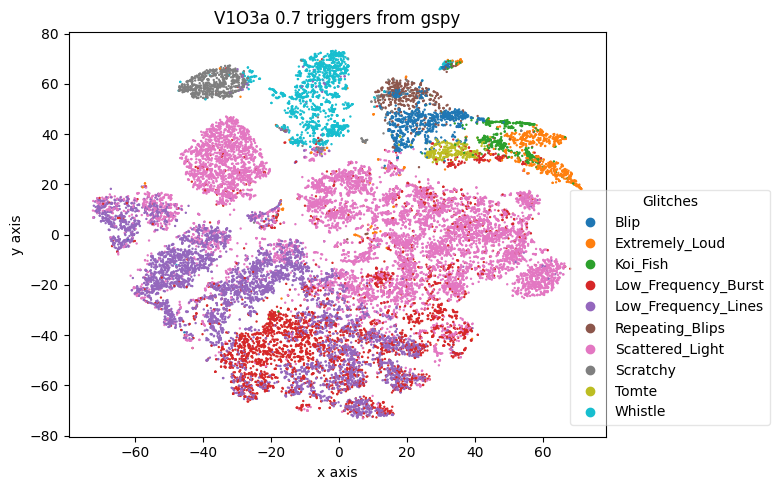

In [156]:
plt.figure(figsize=(8, 5))

cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(pd.Series(labs))

sc = plt.scatter(proj.values[:,0], proj.values[:,1], s=0.5, c=labels, cmap=cmap)
plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center', framealpha=0.5, markerscale=1.0, bbox_to_anchor=(1.12, 0.32))

plt.title(f'V1O3a 0.7 triggers from gspy')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

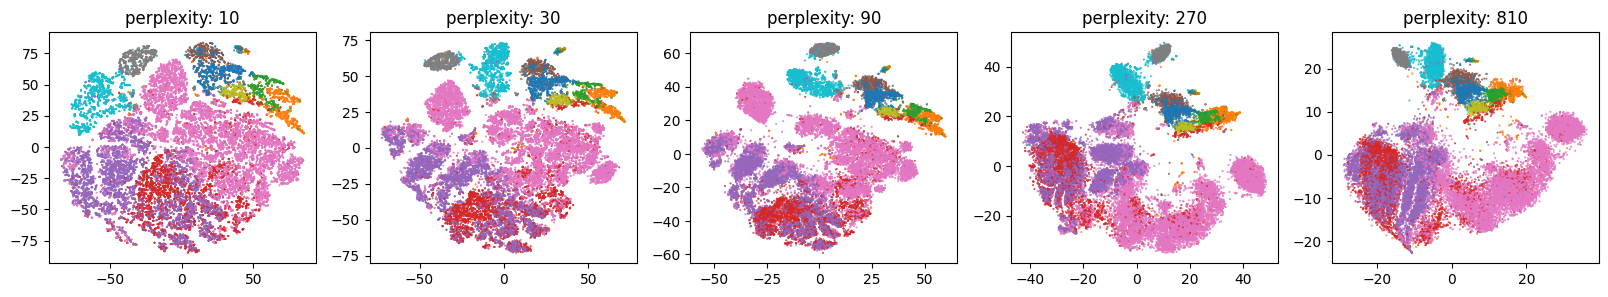

In [145]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, perplexity=p, n_jobs=-1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(np.array(vec))
    # proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj[:,0], proj[:,1], s=0.2, c=labels, cmap=cmap)

plt.show()

### from Francesco clusterization

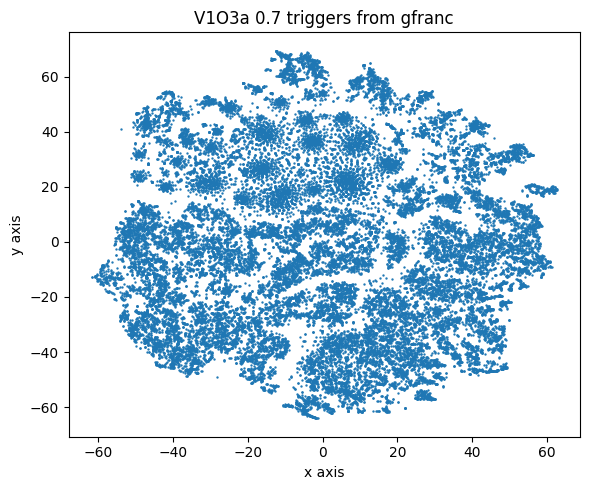

In [20]:
plt.figure(figsize=(6, 5))

sc = plt.scatter(proj.values[:,0], proj.values[:,1], s=0.5)

plt.title(f'V1O3a {tperc} triggers from {clust}')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

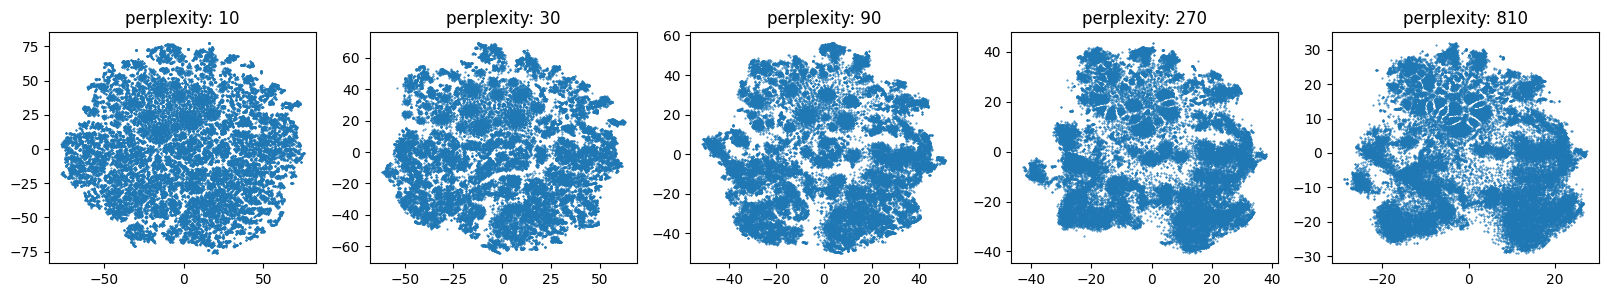

In [22]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, perplexity=p, n_jobs=-1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(np.array(final_vecs))
    # proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj[:,0], proj[:,1], s=0.2)

plt.show()

### from DetChar clusterization

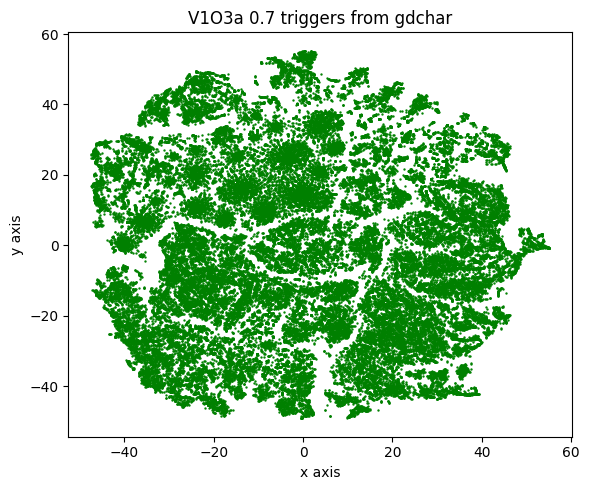

In [47]:
plt.figure(figsize=(6, 5))

sc = plt.scatter(proj.values[:,0], proj.values[:,1], s=0.5, c='green')

plt.title(f'V1O3a {tperc} triggers from {clust}')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

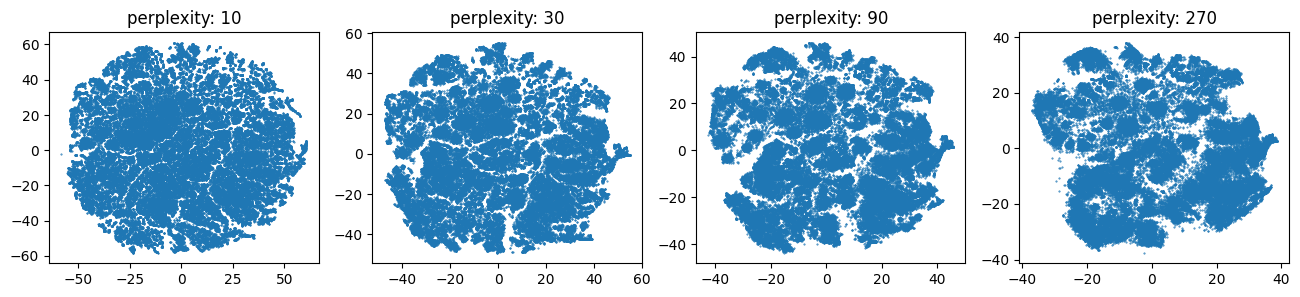

In [11]:
pxs = [10, 30, 90, 270]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, perplexity=p, n_jobs=-1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
    proj = tsne.fit_transform(np.array(final_vecs))
    # proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj[:,0], proj[:,1], s=0.2)

plt.show()